In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RAW_ALL = "Four-Year Heatmap.xlsx"
UNI_LIST = ['Bridgewater', 'Fitchburg', 'Framingham', 'MCLA', 'Salem', 'UMass Amherst', 'UMass Boston', 'UMass Lowell', 'UMass Dartmouth', 'Westfield', 'Worcester']

In [6]:
def make_df(data):
    df = pd.DataFrame()
    for uni in UNI_LIST:
        # Articulation
        art_df = pd.read_excel(data, uni)[:16][['Unnamed: 0', 'MT']] #tbh idk
        art_df.rename(columns={'Unnamed: 0': 'Community Colleges'}, inplace=True) #rename to CCs
        art_df.set_index('Community Colleges', inplace=True) #set indx
        art_df.rename(columns={'MT': uni}, inplace=True) #rename columns to uni names
        df = pd.concat([df, art_df], axis=1) #add each uni to larger df

    return df

In [7]:
def make_mt_heat(df):
    binary_df = df.replace('MT', 1)
    labels = df.to_numpy()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(binary_df, annot=labels, fmt = '', cmap='Blues', vmin=0, vmax=1, cbar=False, linewidths=.5, linecolor='black')

    ax = plt.gca()
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    #customization!
    plt.title('All Existing "A2B-Standard" MassTransfer Agreements in CS')
    plt.ylabel('Community Colleges')
    plt.xlabel('Public 4 Years')
    plt.savefig('images/masstransfer.png', bbox_inches = 'tight')
    plt.show()

    


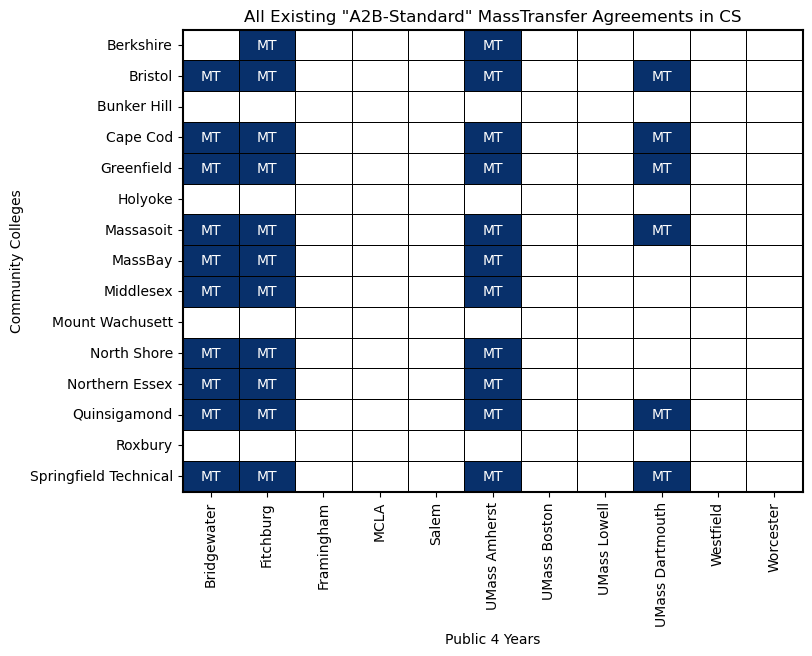

In [8]:
mass_transfer = make_df(RAW_ALL)[:15]
make_mt_heat(mass_transfer)